## Environment and Data Loading

In [37]:
import geopandas as gpd

gdf = gpd.read_file(r"C:\Toronto_Waste\data\clean\grid_250m_master.gpkg")

display(gdf.head())
display(gdf.crs)

,cell_id,bins_total,bins_park_assets,bins_street_furniture,pedestrian_length_m,transit_stops_count,bins_per_km2,stops_per_km2,ped_m_per_km2,bins_per_ped_km,bins_per_stop,geometry
0,0,0,0,0,0.0,0,0.0,0.0,0.0,<NA>,<NA>,"POLYGON ((607837.395 4824768.166, 607837.395 4..."
1,1,0,0,0,0.0,0,0.0,0.0,0.0,<NA>,<NA>,"POLYGON ((607837.395 4825018.166, 607837.395 4..."
2,2,0,0,0,0.0,0,0.0,0.0,0.0,<NA>,<NA>,"POLYGON ((607837.395 4825268.166, 607837.395 4..."
3,3,0,0,0,0.0,0,0.0,0.0,0.0,<NA>,<NA>,"POLYGON ((607837.395 4825518.166, 607837.395 4..."
4,4,0,0,0,0.0,0,0.0,0.0,0.0,<NA>,<NA>,"POLYGON ((607837.395 4825768.166, 607837.395 4..."


<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [38]:
# convert geometry to WKT
gdf["geometry"] = gdf.geometry.to_wkt()

# save as csv
gdf.to_csv("grid_250m_master.csv", index=False)

C:\Users\alexa\AppData\Local\Temp\ipykernel_3524\3441828453.py:2: UserWarning: Geometry column does not contain geometry.
  gdf["geometry"] = gdf.geometry.to_wkt()


In [39]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

file_path = 'grid_250m_master.csv'  
df_raw = pd.read_csv(file_path)

df_raw['geometry'] = df_raw['geometry'].apply(wkt.loads)

gdf = gpd.GeoDataFrame(df_raw, geometry='geometry', crs="EPSG:26917")

print(" Dataset Overview ")
print(gdf.head())
print("\n Data Information")
print(gdf.info())

 Dataset Overview 
   cell_id  bins_total  bins_park_assets  bins_street_furniture  \
0        0           0                 0                      0   
1        1           0                 0                      0   
2        2           0                 0                      0   
3        3           0                 0                      0   
4        4           0                 0                      0   

   pedestrian_length_m  transit_stops_count  bins_per_km2  stops_per_km2  \
0                  0.0                    0           0.0            0.0   
1                  0.0                    0           0.0            0.0   
2                  0.0                    0           0.0            0.0   
3                  0.0                    0           0.0            0.0   
4                  0.0                    0           0.0            0.0   

   ped_m_per_km2  bins_per_ped_km  bins_per_stop  \
0            0.0              NaN            NaN   
1            0.0 

## Descriptive Statistics & Correlation Analysis

--- Descriptive Statistics ---
         bins_total  pedestrian_length_m  transit_stops_count  bins_per_km2  \
count  25024.000000         25024.000000         25024.000000  25024.000000   
mean       0.608416           320.807280             0.369405      9.734655   
std        1.726538           518.559569             1.009629     27.624602   
min        0.000000             0.000000             0.000000      0.000000   
25%        0.000000             0.000000             0.000000      0.000000   
50%        0.000000             0.000000             0.000000      0.000000   
75%        0.000000           602.100060             0.000000      0.000000   
max       30.000000          4010.157540            17.000000    480.000000   

       stops_per_km2  ped_m_per_km2  
count   25024.000000   25024.000000  
mean        5.910486    5132.916482  
std        16.154065    8296.953100  
min         0.000000       0.000000  
25%         0.000000       0.000000  
50%         0.000000       0.

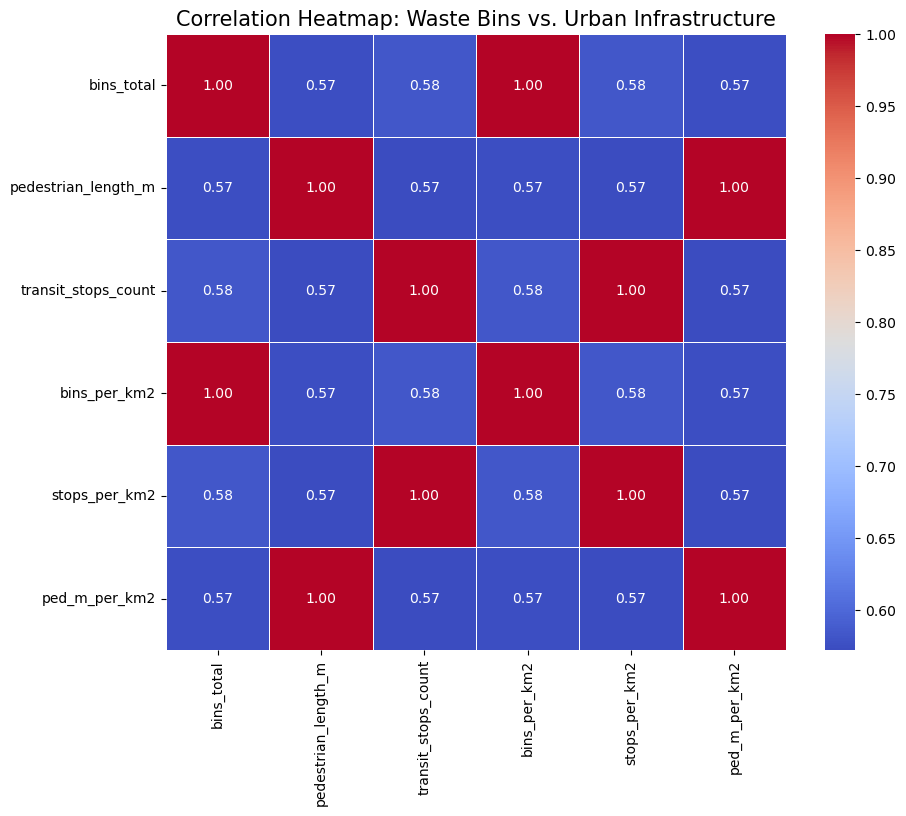


Correlation (Bins vs Pedestrian): 0.575
Correlation (Bins vs Transit): 0.583

Finding: Bins are more closely aligned with transit stops than walking paths.


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_cols = ['bins_total', 'pedestrian_length_m', 'transit_stops_count', 
                 'bins_per_km2', 'stops_per_km2', 'ped_m_per_km2']

print("--- Descriptive Statistics ---")
stats = gdf[analysis_cols].describe()
print(stats)

correlation_matrix = gdf[analysis_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Waste Bins vs. Urban Infrastructure', fontsize=15)
plt.show()

ped_corr = correlation_matrix.loc['bins_total', 'pedestrian_length_m']
transit_corr = correlation_matrix.loc['bins_total', 'transit_stops_count']

print(f"\nCorrelation (Bins vs Pedestrian): {ped_corr:.3f}")
print(f"Correlation (Bins vs Transit): {transit_corr:.3f}")

if ped_corr > transit_corr:
    print("\nFinding: Bins are more closely aligned with walking paths than transit stops.")
else:
    print("\nFinding: Bins are more closely aligned with transit stops than walking paths.")

## Advanced Analytics: K-Means Cluster Analysis

In [41]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['bins_total', 'pedestrian_length_m', 'transit_stops_count']
X = gdf[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
gdf['cluster'] = kmeans.fit_predict(X_scaled)


cluster_profiles = gdf.groupby('cluster')[features].mean().reset_index()

print("Cluster Profiles (Averages per Group)")
print(cluster_profiles)

print("\n Distribution of Cells across Clusters")
print(gdf['cluster'].value_counts())

Cluster Profiles (Averages per Group)
   cluster  bins_total  pedestrian_length_m  transit_stops_count
0        0    0.030012            26.731506             0.025294
1        1    2.273626          1083.088239             2.525900
2        2    9.030508          1472.095544             2.891525
3        3    0.839286           916.031416             0.163497

 Distribution of Cells across Clusters
cluster
0    17593
3     4312
1     2529
2      590
Name: count, dtype: int64


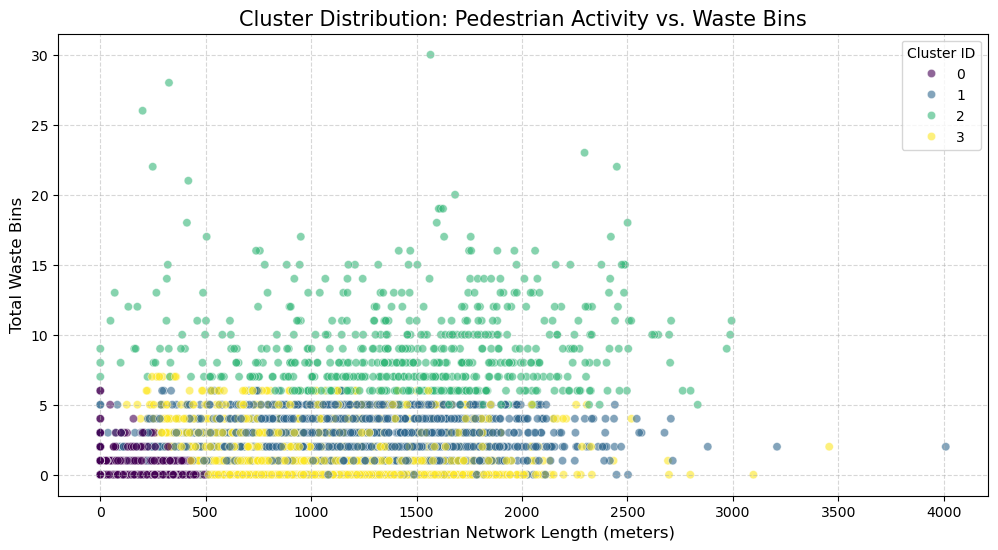

Cluster 0 Statistics:
 - Avg Bins: 0.03
 - Avg Pedestrian Length: 26.73
 - Number of cells: 17593
Cluster 1 Statistics:
 - Avg Bins: 2.27
 - Avg Pedestrian Length: 1083.09
 - Number of cells: 2529
Cluster 2 Statistics:
 - Avg Bins: 9.03
 - Avg Pedestrian Length: 1472.10
 - Number of cells: 590
Cluster 3 Statistics:
 - Avg Bins: 0.84
 - Avg Pedestrian Length: 916.03
 - Number of cells: 4312


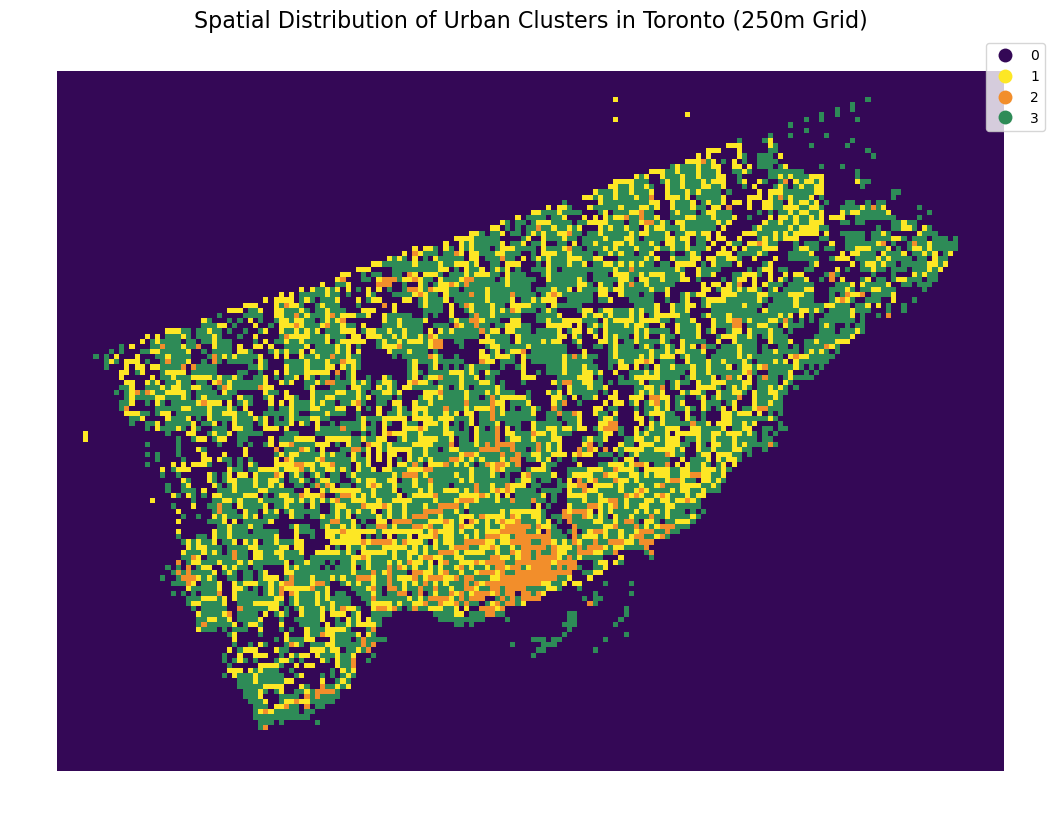

In [58]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(data=gdf, x='pedestrian_length_m', y='bins_total', 
                hue='cluster', palette='viridis', alpha=0.6)

plt.title('Cluster Distribution: Pedestrian Activity vs. Waste Bins', fontsize=15)
plt.xlabel('Pedestrian Network Length (meters)', fontsize=12)
plt.ylabel('Total Waste Bins', fontsize=12)
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(r"C:\Toronto_Waste\outputs\cluster_map.png", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(15, 10))
custom_cmap = ListedColormap([
    '#340856',  # cluster 0 
    '#FDE725',  # cluster 1 
    '#F28E2B',  # cluster 2 
    '#2E8B57'   # cluster 3 
])

gdf.plot(
    column='cluster',
    ax=ax,
    cmap=custom_cmap,
    categorical=True,
    legend=True,
    edgecolor='none'
)

plt.title('Spatial Distribution of Urban Clusters in Toronto (250m Grid)', fontsize=16)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_axis_off()


for i in range(4):
    cluster_data = gdf[gdf['cluster'] == i]
    print(f"Cluster {i} Statistics:")
    print(f" - Avg Bins: {cluster_data['bins_total'].mean():.2f}")
    print(f" - Avg Pedestrian Length: {cluster_data['pedestrian_length_m'].mean():.2f}")
    print(f" - Number of cells: {len(cluster_data)}")

## "Priority List" and a map of the gaps

--- Service Desert Identification ---
Total cells with high pedestrian activity but 0 bins: 675

--- Top 10 Priority Cells (Highest Walking, 0 Bins) ---
       cell_id  pedestrian_length_m  transit_stops_count
3456      3456          3097.853586                    0
21482    21482          2798.569200                    0
9571      9571          2697.476969                    0
12295    12295          2503.170835                    2
14322    14322          2448.604407                    2
10918    10918          2331.447366                    0
11604    11604          2279.042807                    0
13105    13105          2262.407462                    0
11059    11059          2197.360172                    0
16398    16398          2150.227391                    0


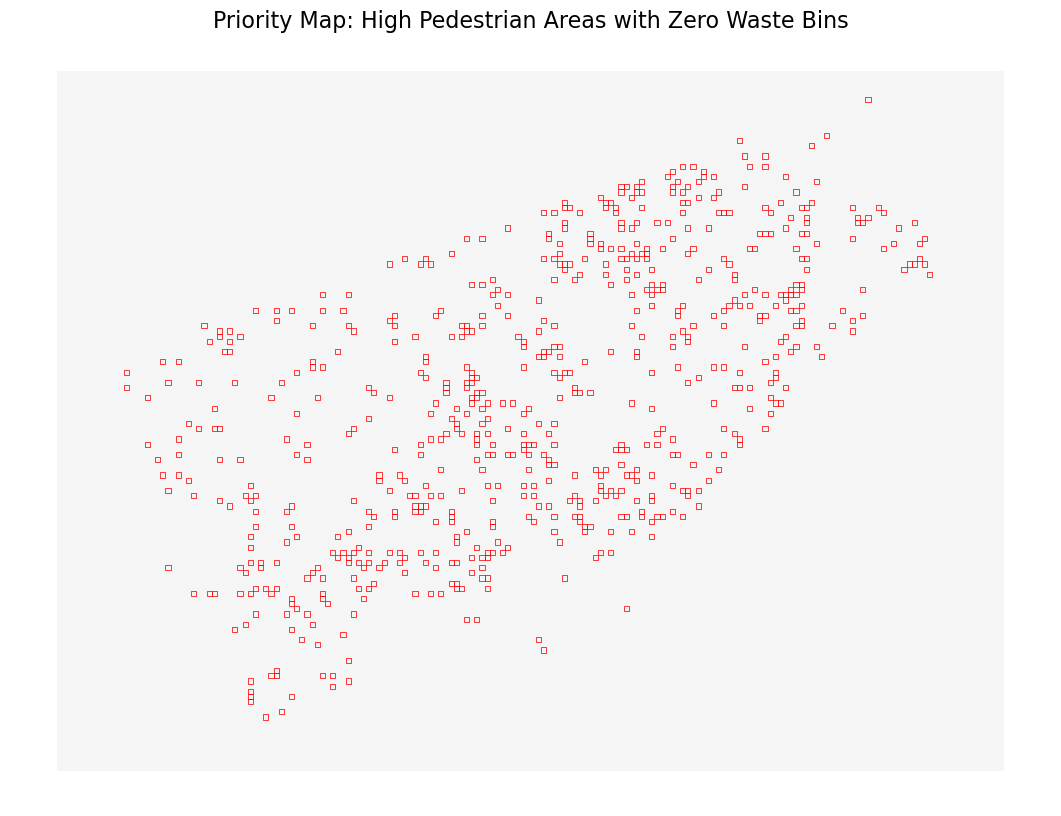

In [70]:
high_walking_threshold = gdf['pedestrian_length_m'].quantile(0.89)

service_deserts = gdf[(gdf['pedestrian_length_m'] > high_walking_threshold) & 
                      (gdf['bins_total'] == 0)].copy()

print(f"--- Service Desert Identification ---")
print(f"Total cells with high pedestrian activity but 0 bins: {len(service_deserts)}")

priority_list = service_deserts.sort_values(by='pedestrian_length_m', ascending=False).head(10)
print("\n--- Top 10 Priority Cells (Highest Walking, 0 Bins) ---")
print(priority_list[['cell_id', 'pedestrian_length_m', 'transit_stops_count']])

fig, ax = plt.subplots(figsize=(15, 10))

gdf.plot(ax=ax, color='whitesmoke', edgecolor='none')

service_deserts.plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    linewidth=0.6,
    alpha=0.9
)

plt.title('Priority Map: High Pedestrian Areas with Zero Waste Bins', fontsize=16)
ax.set_axis_off()
plt.savefig(r"C:\Toronto_Waste\outputs\cluster_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
gdf['priority_flag'] = 0
gdf.loc[service_deserts.index, 'priority_flag'] = 1

gdf['centroid'] = gdf.geometry.centroid
gdf['latitude'] = gdf['centroid'].y
gdf['longitude'] = gdf['centroid'].x

final_export = pd.DataFrame(gdf.drop(columns=['geometry', 'centroid']))

# 4. Save to CSV
final_export.to_csv('toronto_waste_analysis_results.csv', index=False)
print(f"Total rows exported: {len(final_export)}")

Total rows exported: 25024
